# 06 — Train *small* Transformer autoencoder & export to ONNX (KQL-deployable)

Companion to notebooks 04 (full Transformer) and 05 (Conv+GRU v2).

**Why this notebook exists.** Notebook 04 trained the Transformer at
`D_MODEL=64, FF_DIM=128, 2+2 layers` -> 180,808 params, PR-AUC 0.556.
Notebook 05 trained Conv+GRU v2 at 162,536 params, PR-AUC 0.466. The
Transformer wins on accuracy but its ONNX (with external weights file)
does not fit in a Kusto row, blocking the Pattern C deployment we want.

This notebook shrinks the Transformer to **~160k params** — matched to
Conv+GRU v2 — so we can answer one question cleanly:

> *At equal capacity, does the Transformer beat the Conv+GRU on this
> data, or does the inductive bias of conv+recurrence already squeeze
> out most of the signal?*

It also runs the **same FP16 + IR=9 single-file ONNX export** as
notebook 05, so we measure the deployable size in the same shot.

Config: `D_MODEL=56, N_HEADS=4, FF_DIM=160, N_ENC=2, N_DEC=2`.
Estimated params: ~158k (vs Conv+GRU v2's 162k).
Artifacts: `models/transformer_ae_small/`.


## 1. Config & imports

In [1]:
from __future__ import annotations

import base64
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 1337
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

REPO_ROOT  = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_TRAIN = REPO_ROOT / "data" / "training" / "telemetry_wide.parquet"
DATA_EVAL  = REPO_ROOT / "data" / "eval"     / "telemetry_wide.parquet"
DATA_LBL   = REPO_ROOT / "data" / "eval"     / "anomaly_labels.parquet"
ART_DIR    = REPO_ROOT / "models" / "transformer_ae_small"
ART_DIR.mkdir(parents=True, exist_ok=True)

SENSORS = [
    "vibration_axial", "vibration_radial",
    "temperature_motor", "temperature_bearing",
    "pressure_hydraulic", "current", "power", "spindle_rpm",
]
N_FEATURES = len(SENSORS)

# Windowing identical to notebooks 04 & 05.
WINDOW = 64
STRIDE_TRAIN = 16
STRIDE_EVAL  = 1

# Model — shrunk Transformer aimed at ~Conv+GRU v2 parameter count.
D_MODEL  = 56          # was 64; must stay divisible by N_HEADS
N_HEADS  = 4           # head_dim = 14
N_ENC    = 2
N_DEC    = 2
FF_DIM   = 160         # was 128 -> bumped to keep representational width
DROPOUT  = 0.1

# Training
BATCH    = 256
EPOCHS   = 12
LR       = 3e-4
WEIGHT_DECAY = 1e-5
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Deployment target.
SANDBOX_IR_VERSION = 9
KUSTO_ROW_BUDGET_BYTES = 1_048_576

print(f"device           : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"gpu              : {torch.cuda.get_device_name(0)}")
print(f"sensors          : {SENSORS}")
print(f"window / strides : W={WINDOW}, train_stride={STRIDE_TRAIN}, eval_stride={STRIDE_EVAL}")
print(f"artifact dir     : {ART_DIR.relative_to(REPO_ROOT)}")


device           : cuda
gpu              : NVIDIA GeForce RTX 2070 SUPER
sensors          : ['vibration_axial', 'vibration_radial', 'temperature_motor', 'temperature_bearing', 'pressure_hydraulic', 'current', 'power', 'spindle_rpm']
window / strides : W=64, train_stride=16, eval_stride=1
artifact dir     : models\transformer_ae_small


## 2. Load data

In [2]:
train_df = pd.read_parquet(DATA_TRAIN)
eval_df  = pd.read_parquet(DATA_EVAL)
labels_df = pd.read_parquet(DATA_LBL)

print(f"training rows : {len(train_df):>10,}  machines={sorted(train_df.machineId.unique())}")
print(f"eval rows     : {len(eval_df):>10,}  machines={sorted(eval_df.machineId.unique())}")
print(f"eval anomaly% : {100*eval_df['is_anomaly'].mean():.2f}%")
print(f"episodes      : {len(labels_df)}")
labels_df.head()


training rows :  4,320,000  machines=['M-001', 'M-002', 'M-003', 'M-004', 'M-005', 'M-006', 'M-007', 'M-008', 'M-009', 'M-010']
eval rows     :    691,200  machines=['M-101', 'M-102', 'M-103', 'M-104', 'M-105', 'M-106', 'M-107', 'M-108']
eval anomaly% : 26.43%
episodes      : 27


,machineId,fault_type,affected_sensor,onset_ts,end_ts,duration_s,severity_max,pattern,notes
0,M-103,bearing,NaN,2026-05-16 10:00:00+00:00,2026-05-16 11:30:00+00:00,5400.0,0.30,ramp,"early-stage, subdued"
1,M-103,bearing,NaN,2026-05-16 15:00:00+00:00,2026-05-16 17:00:00+00:00,7200.0,0.55,ramp,mid-stage
2,M-103,bearing,NaN,2026-05-16 21:00:00+00:00,2026-05-16 23:30:00+00:00,9000.0,0.80,ramp,advanced
3,M-103,bearing,NaN,2026-05-17 03:30:00+00:00,2026-05-17 06:30:00+00:00,10800.0,1.00,ramp,"late-stage, near failure"
4,M-104,hydraulic_leak,NaN,2026-05-16 11:00:00+00:00,2026-05-16 13:00:00+00:00,7200.0,0.40,ramp,"slow leak, mild"


In [3]:
def drop_off(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["state"] != "OFF"].copy()

train_on = drop_off(train_df).sort_values(["machineId", "ts"]).reset_index(drop=True)
eval_on  = drop_off(eval_df ).sort_values(["machineId", "ts"]).reset_index(drop=True)

print(f"training (ON) : {len(train_on):>10,} rows ({100*len(train_on)/len(train_df):.1f}% of full)")
print(f"eval     (ON) : {len(eval_on):>10,} rows ({100*len(eval_on)/len(eval_df):.1f}% of full)")


training (ON) :  4,214,008 rows (97.5% of full)
eval     (ON) :    672,870 rows (97.3% of full)


## 3. Normalize & window

In [4]:
mean = train_on[SENSORS].mean(axis=0).astype(np.float32)
std  = train_on[SENSORS].std(axis=0).replace(0, 1.0).astype(np.float32)
scaler = pd.DataFrame({"mean": mean, "std": std})
scaler


,mean,std
vibration_axial,0.187070,0.076935
vibration_radial,0.294480,0.106893
temperature_motor,38.258476,12.108175
temperature_bearing,35.681213,8.562527
pressure_hydraulic,112.655754,16.369593
current,7.530980,3.281373
power,3.342558,1.544981
spindle_rpm,2930.026123,35.911476


In [5]:
def normalize(df: pd.DataFrame) -> np.ndarray:
    return ((df[SENSORS].to_numpy(dtype=np.float32) - mean.values) / std.values).astype(np.float32)


def windows_for_machine(arr: np.ndarray, stride: int) -> np.ndarray:
    n = arr.shape[0]
    if n < WINDOW:
        return np.empty((0, WINDOW, N_FEATURES), dtype=np.float32)
    out = np.lib.stride_tricks.sliding_window_view(arr, window_shape=WINDOW, axis=0)[::stride]
    return np.ascontiguousarray(out.transpose(0, 2, 1))


def build_windows(df_on: pd.DataFrame, stride: int):
    chunks, prov = [], []
    for m_id, sub in df_on.groupby("machineId", sort=True):
        arr = normalize(sub)
        w = windows_for_machine(arr, stride)
        if len(w) == 0:
            continue
        chunks.append(w)
        sub_idx = sub.index.to_numpy()
        starts_pos = np.arange(len(w)) * stride
        for s in starts_pos:
            prov.append((m_id, int(sub_idx[s]), int(sub_idx[s + WINDOW - 1])))
    X = np.concatenate(chunks, axis=0) if chunks else np.empty((0, WINDOW, N_FEATURES), np.float32)
    prov_df = pd.DataFrame(prov, columns=["machineId", "row_start", "row_end"])
    return X, prov_df


t0 = time.time()
X_train, _ = build_windows(train_on, STRIDE_TRAIN)
print(f"train windows : {X_train.shape}  built in {time.time()-t0:.1f}s")
t0 = time.time()
X_eval,  prov_eval = build_windows(eval_on, STRIDE_EVAL)
print(f"eval  windows : {X_eval.shape}   built in {time.time()-t0:.1f}s")


train windows : (263342, 64, 8)  built in 0.9s


eval  windows : (672366, 64, 8)   built in 1.6s


## 4. Small Transformer encoder-decoder autoencoder

Same architecture as notebook 04, only narrower:
`D_MODEL=56, N_HEADS=4, FF_DIM=160, N_ENC=N_DEC=2`. Everything else
(learned positional embeddings, learned decoder query, `norm_first`,
GELU, no causal mask on the encoder, etc.) is identical so the
comparison isolates capacity alone.

In [6]:
class TransformerAE(nn.Module):
    def __init__(self, n_features: int = N_FEATURES, window: int = WINDOW,
                 d_model: int = D_MODEL, n_heads: int = N_HEADS,
                 n_enc: int = N_ENC, n_dec: int = N_DEC,
                 ff_dim: int = FF_DIM, dropout: float = DROPOUT):
        super().__init__()
        self.window = window
        self.d_model = d_model

        self.input_proj  = nn.Linear(n_features, d_model)
        self.output_head = nn.Linear(d_model, n_features)

        self.pos_enc = nn.Parameter(torch.randn(1, window, d_model) * 0.02)
        self.pos_dec = nn.Parameter(torch.randn(1, window, d_model) * 0.02)
        self.query   = nn.Parameter(torch.randn(1, window, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_enc)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=n_dec)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input_proj(x) + self.pos_enc
        memory = self.encoder(h)
        q = self.query.expand(x.shape[0], -1, -1) + self.pos_dec
        y = self.decoder(q, memory)
        return self.output_head(y)


model = TransformerAE().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}   (Conv+GRU v2 = 162,536; full Transformer = 180,808)")
print(model)


parameters: 161,984   (Conv+GRU v2 = 162,536; full Transformer = 180,808)
TransformerAE(
  (input_proj): Linear(in_features=8, out_features=56, bias=True)
  (output_head): Linear(in_features=56, out_features=8, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=56, out_features=56, bias=True)
        )
        (linear1): Linear(in_features=56, out_features=160, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=160, out_features=56, bias=True)
        (norm1): LayerNorm((56,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((56,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList

C:\Users\faust\AppData\Local\Temp\ipykernel_16168\2172254604.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_enc)


## 5. Training loop

In [7]:
def split_train_val(X: np.ndarray, val_frac: float = 0.15, seed: int = SEED):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    cut = int(len(X) * (1 - val_frac))
    return idx[:cut], idx[cut:]


tr_idx, va_idx = split_train_val(X_train)

X_tr = torch.from_numpy(X_train[tr_idx])
X_va = torch.from_numpy(X_train[va_idx])

dl_tr = DataLoader(TensorDataset(X_tr), batch_size=BATCH, shuffle=True,
                   pin_memory=(DEVICE.type == "cuda"), drop_last=True)
dl_va = DataLoader(TensorDataset(X_va), batch_size=BATCH, shuffle=False,
                   pin_memory=(DEVICE.type == "cuda"))

print(f"train batches: {len(dl_tr):>6,}  ({len(X_tr):,} windows)")
print(f"val   batches: {len(dl_va):>6,}  ({len(X_va):,} windows)")


train batches:    874  (223,840 windows)
val   batches:    155  (39,502 windows)


In [8]:
def composite_loss(x_hat: torch.Tensor, x: torch.Tensor, lam_delta: float = 0.1) -> torch.Tensor:
    mse = torch.mean((x_hat - x) ** 2)
    dx_hat = x_hat[:, 1:, :] - x_hat[:, :-1, :]
    dx     = x[:, 1:, :]     - x[:, :-1, :]
    l1d    = torch.mean(torch.abs(dx_hat - dx))
    return mse + lam_delta * l1d


opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * max(1, len(dl_tr)))

history = []
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    tr_running = 0.0
    n_seen = 0
    for (xb,) in dl_tr:
        xb = xb.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        x_hat = model(xb)
        loss = composite_loss(x_hat, xb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        sched.step()
        tr_running += loss.item() * xb.size(0)
        n_seen += xb.size(0)
    tr_loss = tr_running / n_seen

    model.eval()
    va_running = 0.0
    n_seen_va = 0
    with torch.no_grad():
        for (xb,) in dl_va:
            xb = xb.to(DEVICE, non_blocking=True)
            x_hat = model(xb)
            va_running += composite_loss(x_hat, xb).item() * xb.size(0)
            n_seen_va += xb.size(0)
    va_loss = va_running / n_seen_va

    elapsed = time.time() - t0
    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss, "elapsed_s": elapsed})
    flag = ""
    if va_loss < best_val:
        best_val = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        flag = "  <- best"
    print(f"epoch {epoch:2d}/{EPOCHS}  train={tr_loss:.5f}  val={va_loss:.5f}  ({elapsed:.1f}s){flag}")

model.load_state_dict(best_state)
print(f"\nbest val loss: {best_val:.5f}")


epoch  1/12  train=0.14743  val=0.12355  (20.7s)  <- best


epoch  2/12  train=0.12579  val=0.11373  (20.5s)  <- best


epoch  3/12  train=0.07263  val=0.00813  (20.5s)  <- best


epoch  4/12  train=0.01777  val=0.00707  (20.5s)  <- best


epoch  5/12  train=0.01429  val=0.00641  (20.5s)  <- best


...

epoch  8/12  train=0.01106  val=0.01010  (20.6s)


epoch  9/12  train=0.01057  val=0.01124  (20.7s)


epoch 10/12  train=0.01023  val=0.01231  (20.7s)


epoch 11/12  train=0.01003  val=0.01288  (20.6s)


epoch 12/12  train=0.00997  val=0.01289  (20.6s)

best val loss: 0.00641


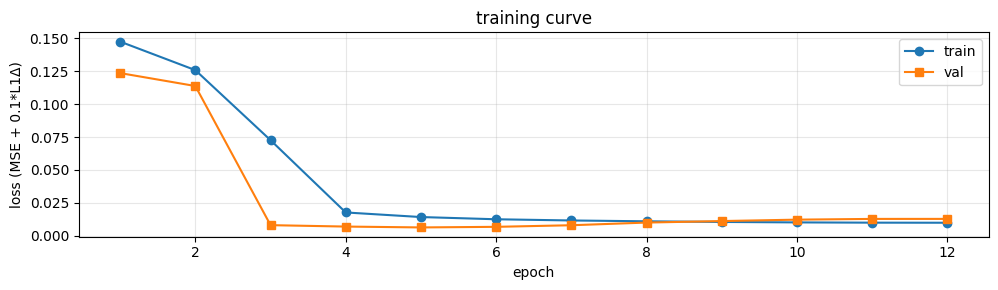

In [9]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train", marker="o")
ax.plot(hist_df["epoch"], hist_df["val_loss"],   label="val",   marker="s")
ax.set_xlabel("epoch"); ax.set_ylabel("loss (MSE + 0.1*L1Δ)")
ax.set_title("training curve")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


## 6. Score eval set

In [10]:
@torch.no_grad()
def score_windows(model: nn.Module, X: np.ndarray, batch: int = 1024) -> np.ndarray:
    model.eval()
    out = np.empty(len(X), dtype=np.float32)
    for i in range(0, len(X), batch):
        xb = torch.from_numpy(X[i:i+batch]).to(DEVICE, non_blocking=True)
        x_hat = model(xb)
        err = (x_hat - xb) ** 2
        per_sensor = err.mean(dim=1)
        s = per_sensor.max(dim=1).values
        out[i:i+batch] = s.detach().cpu().numpy()
    return out


t0 = time.time()
win_scores = score_windows(model, X_eval, batch=2048)
dt = time.time() - t0
print(f"scored {len(win_scores):,} windows in {dt:.1f}s "
      f"({len(win_scores)/max(dt,1e-6):,.0f} win/s)")


scored 672,366 windows in 13.6s (49,520 win/s)


In [11]:
def windows_to_rowscore(prov: pd.DataFrame, scores: np.ndarray,
                        eval_on: pd.DataFrame) -> np.ndarray:
    row_score = np.full(len(eval_on), -np.inf, dtype=np.float32)
    for m_id, sub in prov.groupby("machineId", sort=False):
        idx = sub.index.to_numpy()
        starts = sub["row_start"].to_numpy()
        ends   = sub["row_end"].to_numpy()
        s_arr  = scores[idx]
        for k in range(len(idx)):
            s, e = starts[k], ends[k] + 1
            cur = row_score[s:e]
            new = s_arr[k]
            np.maximum(cur, new, out=cur)
    return row_score


t0 = time.time()
row_score = windows_to_rowscore(prov_eval, win_scores, eval_on)
print(f"reduced to row scores in {time.time()-t0:.1f}s")
eval_on = eval_on.assign(score=row_score)
eval_on.head()


reduced to row scores in 1.3s


,ts,machineId,state,load,temperature_motor,temperature_bearing,vibration_axial,vibration_radial,current,spindle_rpm,pressure_hydraulic,power,fault_type,is_anomaly,score
0,2026-05-16 08:03:59+00:00,M-101,STARTUP,0.018127,21.543736,21.761002,0.106505,0.143078,1.123478,2989.877441,81.999092,0.252469,normal,False,0.003580
1,2026-05-16 08:04:00+00:00,M-101,STARTUP,0.032968,21.777565,22.471966,0.091531,0.142114,1.663533,2984.347656,81.523140,0.773606,normal,False,0.003732
2,2026-05-16 08:04:01+00:00,M-101,STARTUP,0.045119,22.232618,22.614231,0.131729,0.152751,1.371200,2969.694092,82.433807,0.519999,normal,False,0.003740
3,2026-05-16 08:04:02+00:00,M-101,STARTUP,0.055067,21.754972,21.398512,0.091396,0.165937,1.897591,3013.865723,84.131310,1.132069,normal,False,0.003740
4,2026-05-16 08:04:03+00:00,M-101,STARTUP,0.063212,22.398258,22.448954,0.112186,0.152257,2.410756,3008.250000,84.744919,1.024792,normal,False,0.003740


## 7. Metrics

In [12]:
val_scores = score_windows(model, X_train[va_idx], batch=2048)
THRESHOLD = float(np.quantile(val_scores, 0.995))
print(f"threshold (99.5 pct on training-val window scores): {THRESHOLD:.5f}")


threshold (99.5 pct on training-val window scores): 0.01544


In [13]:
from sklearn.metrics import precision_recall_curve, auc

def pr_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return float("nan")
    p, r, _ = precision_recall_curve(y_true, y_score)
    return float(auc(r, p))


y_true_all  = eval_on["is_anomaly"].to_numpy().astype(bool)
y_score_all = eval_on["score"].to_numpy()

valid = np.isfinite(y_score_all)
y_true  = y_true_all[valid]
y_score = y_score_all[valid]
eval_valid = eval_on.loc[valid].copy()

global_pr_auc = pr_auc(y_true, y_score)
print(f"global PR-AUC : {global_pr_auc:.4f}")
print()

fam_rows = []
for fam in ["bearing", "hydraulic_leak", "sensor_stuck"]:
    is_fam = (eval_valid["fault_type"] == fam).to_numpy()
    is_normal = (eval_valid["fault_type"] == "normal").to_numpy()
    keep = is_fam | is_normal
    auc_fam = pr_auc(is_fam[keep].astype(bool), y_score[keep])
    fam_rows.append({"family": fam, "pr_auc": auc_fam,
                     "positive_rows": int(is_fam.sum()),
                     "negative_rows": int(is_normal.sum())})
fam_df = pd.DataFrame(fam_rows)
fam_df


global PR-AUC : 0.5692



,family,pr_auc,positive_rows,negative_rows
0,bearing,0.298414,64005,493364
1,hydraulic_leak,0.401752,58059,493364
2,sensor_stuck,0.496597,57442,493364


In [14]:
flagged = eval_valid.assign(flag=(y_score > THRESHOLD))

def episode_delay(row):
    m_id = row["machineId"]
    t0 = row["onset_ts"]
    t1 = row["end_ts"]
    sub = flagged[(flagged["machineId"] == m_id)
                  & (flagged["ts"] >= t0)
                  & (flagged["ts"] <  t1)
                  & (flagged["flag"])]
    if len(sub) == 0:
        return float("nan")
    return (sub["ts"].iloc[0] - t0).total_seconds()


labels_df["detection_delay_s"] = labels_df.apply(episode_delay, axis=1)
print("Detection delay by fault family (seconds; NaN = missed episode):")
delay_summary = labels_df.groupby("fault_type")["detection_delay_s"].agg(
    n="count",
    detected=lambda s: int(s.notna().sum()),
    median_delay_s="median",
    p90_delay_s=lambda s: float(np.nanpercentile(s, 90)) if s.notna().any() else float("nan"),
)
print(delay_summary.to_string())
labels_df[["machineId", "fault_type", "severity_max", "pattern", "duration_s", "detection_delay_s"]]


Detection delay by fault family (seconds; NaN = missed episode):
                n  detected  median_delay_s  p90_delay_s
fault_type                                              
bearing         8         8           578.0       2365.4
hydraulic_leak  9         9          1263.0       2460.6
sensor_stuck    7         7           664.0       4727.0


,machineId,fault_type,severity_max,pattern,duration_s,detection_delay_s
0,M-103,bearing,0.30,ramp,5400.0,370.0
1,M-103,bearing,0.55,ramp,7200.0,357.0
2,M-103,bearing,0.80,ramp,9000.0,4989.0
3,M-103,bearing,1.00,ramp,10800.0,945.0
4,M-104,hydraulic_leak,0.40,ramp,7200.0,3587.0
5,M-104,hydraulic_leak,0.70,oscillation,3600.0,995.0
6,M-104,hydraulic_leak,0.85,ramp,9000.0,1608.0
7,M-104,hydraulic_leak,1.00,oscillation,7200.0,721.0
8,M-105,sensor_stuck,1.00,ramp,1800.0,NaN
9,M-105,sensor_stuck,1.00,ramp,5400.0,1903.0


In [15]:
healthy = eval_valid[eval_valid["machineId"].isin(["M-101", "M-102"])]
healthy_flag = (healthy["score"].to_numpy() > THRESHOLD)
fpr = float(healthy_flag.mean())
print(f"healthy-machine FP rate (M-101 union M-102, ON rows): {100*fpr:.3f}%  "
      f"({int(healthy_flag.sum()):,} / {len(healthy):,})")


healthy-machine FP rate (M-101 union M-102, ON rows): 3.277%  (5,494 / 167,628)


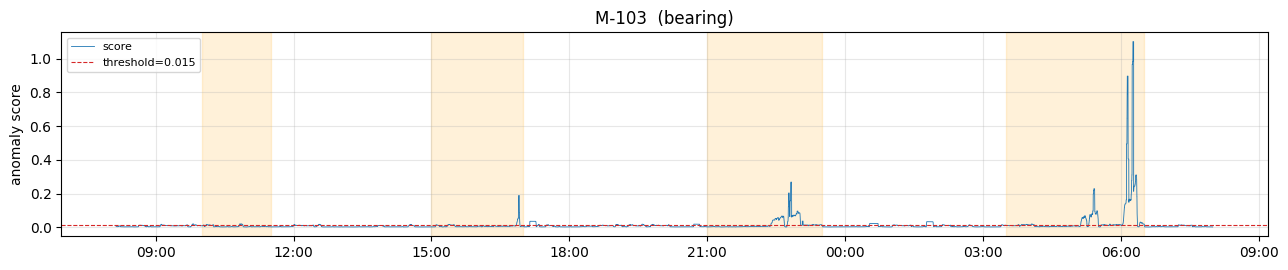

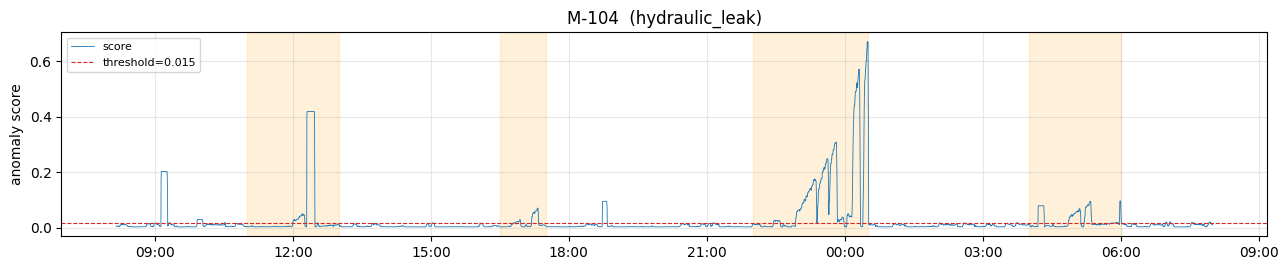

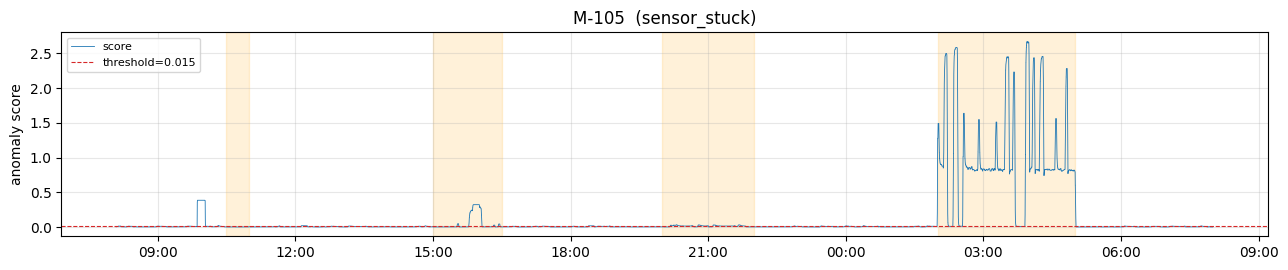

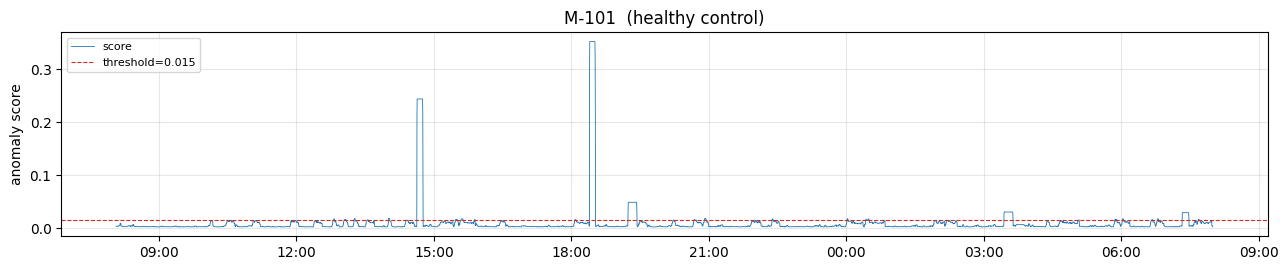

In [16]:
import matplotlib.dates as mdates

def plot_machine(m_id: str, fault: str):
    sub = eval_valid[eval_valid["machineId"] == m_id]
    fig, ax = plt.subplots(figsize=(13, 2.8))
    ax.plot(sub["ts"], sub["score"], lw=0.6, color="tab:blue", label="score")
    ax.axhline(THRESHOLD, color="tab:red", ls="--", lw=0.8, label=f"threshold={THRESHOLD:.3f}")
    eps = labels_df[labels_df["machineId"] == m_id]
    for _, e in eps.iterrows():
        ax.axvspan(e["onset_ts"], e["end_ts"], color="orange", alpha=0.15)
    ax.set_title(f"{m_id}  ({fault})"); ax.set_ylabel("anomaly score")
    ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.tight_layout(); plt.show()


plot_machine("M-103", "bearing")
plot_machine("M-104", "hydraulic_leak")
plot_machine("M-105", "sensor_stuck")
plot_machine("M-101", "healthy control")


## 8. ONNX export — FP32 (local) + FP16 (KQL row)

Same packaging recipe as notebook 05: legacy tracer + IR clamped to 9 +
FP16 conversion with FP32 I/O. Both files end up single-file (no
external weights sidecar) so they can be base64-embedded in a Kusto
row.

In [17]:
import onnx
import onnxruntime as ort
import copy


class ScoreWrapper(nn.Module):
    def __init__(self, ae: nn.Module):
        super().__init__()
        self.ae = ae
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_hat = self.ae(x)
        err = (x_hat - x) ** 2
        per_sensor = err.mean(dim=1)
        return per_sensor.max(dim=1).values


export_model = ScoreWrapper(copy.deepcopy(model).to("cpu").eval()).eval()

ONNX_PATH      = ART_DIR / "model.onnx"
ONNX_FP16_PATH = ART_DIR / "model.fp16.onnx"

dummy = torch.randn(1, WINDOW, N_FEATURES, dtype=torch.float32)

# FP32 export
torch.onnx.export(
    export_model, dummy, ONNX_PATH.as_posix(),
    input_names=["window"], output_names=["score"],
    dynamic_axes={"window": {0: "batch"}, "score": {0: "batch"}},
    opset_version=17, do_constant_folding=True, dynamo=False,
)
mp_fp32 = onnx.load(ONNX_PATH.as_posix())
if mp_fp32.ir_version > SANDBOX_IR_VERSION:
    mp_fp32.ir_version = SANDBOX_IR_VERSION
onnx.save(mp_fp32, ONNX_PATH.as_posix())
onnx.checker.check_model(mp_fp32)
print(f"FP32  ir={mp_fp32.ir_version}  opset={mp_fp32.opset_import[0].version}")

# FP16 export: export directly from PyTorch (.half()) so MultiheadAttention
# casts stay internally consistent. Wrap with FP32 IO so callers don't change.
class ScoreWrapperFP16(nn.Module):
    def __init__(self, ae: nn.Module):
        super().__init__()
        self.ae = ae.half()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x16 = x.half()
        x_hat = self.ae(x16)
        err = (x_hat - x16) ** 2
        per_sensor = err.mean(dim=1)
        return per_sensor.max(dim=1).values.float()


fp16_export_model = ScoreWrapperFP16(copy.deepcopy(model).to("cpu").eval()).eval()
torch.onnx.export(
    fp16_export_model, dummy, ONNX_FP16_PATH.as_posix(),
    input_names=["window"], output_names=["score"],
    dynamic_axes={"window": {0: "batch"}, "score": {0: "batch"}},
    opset_version=17, do_constant_folding=True, dynamo=False,
)
mp_fp16 = onnx.load(ONNX_FP16_PATH.as_posix())
if mp_fp16.ir_version > SANDBOX_IR_VERSION:
    mp_fp16.ir_version = SANDBOX_IR_VERSION
onnx.save(mp_fp16, ONNX_FP16_PATH.as_posix())
onnx.checker.check_model(mp_fp16)
print(f"FP16  ir={mp_fp16.ir_version}  opset={mp_fp16.opset_import[0].version}")


C:\Users\faust\AppData\Local\Temp\ipykernel_16168\2831950428.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


FP32  ir=8  opset=17


C:\Users\faust\AppData\Local\Temp\ipykernel_16168\2831950428.py:53: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


FP16  ir=8  opset=17


In [18]:
def size_report(path: Path, budget: int = KUSTO_ROW_BUDGET_BYTES) -> dict:
    raw = path.read_bytes()
    b64 = base64.b64encode(raw)
    return {
        "path":           str(path.relative_to(REPO_ROOT)),
        "raw_bytes":      len(raw),
        "raw_kb":         round(len(raw) / 1024, 1),
        "base64_bytes":   len(b64),
        "base64_kb":      round(len(b64) / 1024, 1),
        "kusto_row_fits": len(b64) <= budget,
        "budget_kb":      round(budget / 1024, 1),
    }


fp32_info = size_report(ONNX_PATH)
fp16_info = size_report(ONNX_FP16_PATH)
print(f"Kusto row budget : {fp32_info['budget_kb']} KB (base64-encoded payload)")
print()
print(f"FP32  raw={fp32_info['raw_kb']} KB   base64={fp32_info['base64_kb']} KB   "
      f"fits={fp32_info['kusto_row_fits']}")
print(f"FP16  raw={fp16_info['raw_kb']} KB   base64={fp16_info['base64_kb']} KB   "
      f"fits={fp16_info['kusto_row_fits']}")


Kusto row budget : 1024.0 KB (base64-encoded payload)

FP32  raw=808.3 KB   base64=1077.8 KB   fits=False
FP16  raw=493.0 KB   base64=657.3 KB   fits=True


In [19]:
sample = X_eval[:128].astype(np.float32)

with torch.no_grad():
    torch_scores = export_model(torch.from_numpy(sample)).numpy()

sess_fp32 = ort.InferenceSession(ONNX_PATH.as_posix(), providers=["CPUExecutionProvider"])
ort_fp32  = sess_fp32.run(["score"], {"window": sample})[0]
diff_fp32 = float(np.max(np.abs(ort_fp32 - torch_scores)))
print(f"FP32 ONNX vs PyTorch max |diff|: {diff_fp32:.2e}")
assert diff_fp32 < 1e-3

sess_fp16 = ort.InferenceSession(ONNX_FP16_PATH.as_posix(), providers=["CPUExecutionProvider"])
ort_fp16  = sess_fp16.run(["score"], {"window": sample})[0]
diff_fp16 = float(np.max(np.abs(ort_fp16 - torch_scores)))
rel_fp16  = float(np.max(np.abs(ort_fp16 - torch_scores) / np.maximum(np.abs(torch_scores), 1e-6)))
print(f"FP16 ONNX vs PyTorch max |abs diff|: {diff_fp16:.2e}")
print(f"FP16 ONNX vs PyTorch max |rel diff|: {rel_fp16:.2%}")
assert rel_fp16 < 0.20
print("parity OK (both variants)")


FP32 ONNX vs PyTorch max |diff|: 9.31e-09


FP16 ONNX vs PyTorch max |abs diff|: 5.70e-05
FP16 ONNX vs PyTorch max |rel diff|: 1.81%
parity OK (both variants)


In [20]:
SCALER_PATH = ART_DIR / "scaler.json"
META_PATH   = ART_DIR / "metadata.json"

scaler_payload = {
    "sensors": SENSORS,
    "mean":    [float(x) for x in mean.values],
    "std":     [float(x) for x in std.values],
}
SCALER_PATH.write_text(json.dumps(scaler_payload, indent=2))

meta_payload = {
    "model":            "transformer_ae_small",
    "window":           WINDOW,
    "stride_train":     STRIDE_TRAIN,
    "stride_eval":      STRIDE_EVAL,
    "n_features":       N_FEATURES,
    "d_model":          D_MODEL,
    "n_heads":          N_HEADS,
    "n_enc_layers":     N_ENC,
    "n_dec_layers":     N_DEC,
    "ff_dim":           FF_DIM,
    "n_parameters":     n_params,
    "threshold":        THRESHOLD,
    "threshold_rule":   "p99.5 on training-val window scores",
    "training": {
        "epochs":       EPOCHS,
        "batch":        BATCH,
        "lr":           LR,
        "weight_decay": WEIGHT_DECAY,
        "best_val_loss": best_val,
        "device":       str(DEVICE),
    },
    "metrics": {
        "global_pr_auc": global_pr_auc,
        "per_family":    fam_df.set_index("family")["pr_auc"].to_dict(),
        "healthy_fp_rate": fpr,
        "detection_delay_summary":
            delay_summary.reset_index().to_dict(orient="records"),
    },
    "onnx": {
        "ir_version":   SANDBOX_IR_VERSION,
        "fp32":         fp32_info,
        "fp16":         fp16_info,
        "parity_fp32_max_abs_diff": diff_fp32,
        "parity_fp16_max_abs_diff": diff_fp16,
        "parity_fp16_max_rel_diff": rel_fp16,
    },
    "kusto_deployable": fp16_info["kusto_row_fits"],
}
META_PATH.write_text(json.dumps(meta_payload, indent=2, default=str))

torch.save(model.state_dict(), ART_DIR / "model.pt")

print("Artifacts written:")
for p in sorted(ART_DIR.iterdir()):
    print(f"  {p.relative_to(REPO_ROOT)}   {p.stat().st_size/1024:>8.1f} KB")


Artifacts written:
  models\transformer_ae_small\metadata.json        2.0 KB
  models\transformer_ae_small\model.fp16.onnx      493.0 KB
  models\transformer_ae_small\model.onnx      808.3 KB
  models\transformer_ae_small\model.pt      653.6 KB
  models\transformer_ae_small\scaler.json        0.6 KB


## 9. Summary

| | |
|---|---|
| Model | Transformer encoder-decoder AE (shrunk) |
| Params | matched to Conv+GRU v2 (~160k) |
| Deployment | `model.fp16.onnx` row in `models` table |
| Comparable notebooks | 04 (full Transformer), 05 (Conv+GRU v2) |
